# installation:

this notebook uses pymc_env
~~~python
conda install numpyro
conda install -c conda-forge nutpie
conda create -c conda-forge -n pymc_env "pymc>=5"
conda activate pymc_env
%conda install -c conda-forge ipywidgets
~~~

In [2]:
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.0.1


In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

In [5]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

In [6]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y _obs", mu=mu, sigma=sigma, observed=Y)

# Bayes Theorem

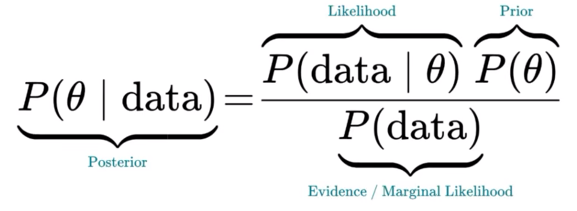

We design the Prior based on a distribution.

and 
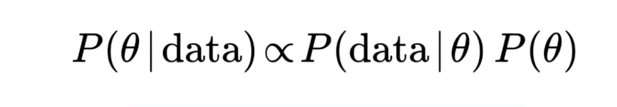

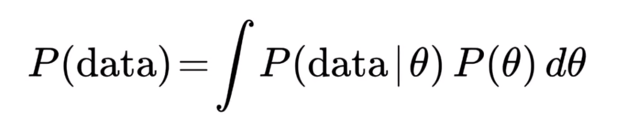

computational challenge. MCMC (Markov Chain Monte Carlo)




In [7]:
data = np.arange(1, 11, 1)

with pm.Model() as model:
    
    # all random variables go here
    mu = pm.Normal('mu', mu=0, sigma=10)
    

    # PyMC tracks relationship automatically
    x = pm.Normal('x', mu=mu, sigma=1, observed=data)

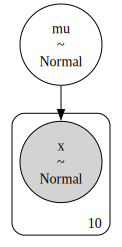

In [8]:
pm.model_to_graphviz(model)

In [9]:
# Example 2:

with pm.Model() as model:

    # Unobserved (parameters to estimate)
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1) # no puede ser negativo

    # Deterministic transformations
    scaled_mu = pm.Deterministic('scaled_mu', mu*2)

    # Observed (your data)
    y = pm.Normal('y', mu=mu, sigma=sigma)


Hiperparámetros (fijos o con su propio prior)
        ↓
    Priors (distribuciones sobre parámetros)
        ↓
    Likelihood (cómo los datos dependen de los parámetros)
        ↓
    Posterior (prior actualizado con los datos)

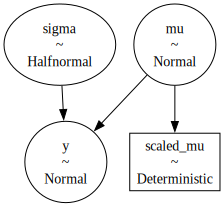

In [10]:
pm.model_to_graphviz(model)

Example the Bioassay Problem

Teh questions:
How does drug dose affect mortality in lab animals?

In [11]:
dose = np.array([-0.86, -0.3, -0.05, 0.73])
animals = np.array([5, 5, 5, 5])
deaths = np.array([0, 1, 3, 5])


In [12]:

with pm.Model() as bio_model:

    dose_data = pm.Data('dose_data', dose)
    deaths_data = pm.Data('deaths_data', deaths)

    alpha = pm.Normal('alpha', mu=0, sigma=2.5)
    beta = pm.Normal('beta', mu=0, sigma=2.5)

    theta = pm.math.invlogit(alpha + beta * dose_data)

    deaths_model = pm.Binomial('deaths', n=animals, p=theta, observed=deaths_data)



In [13]:
deaths

array([0, 1, 3, 5])

In [14]:
coord = {
    'coefs': ['intercept', 'slope'],
    'obs': list(np.arange(4))
}

with pm.Model(coords=coord) as dose_model:

    dose_data = pm.Data('dose_data', dose)
    deaths_data = pm.Data('deaths_data', deaths)

    # vector of coefficients, indexed by labelled dimensions
    beta = pm.Normal('beta0', 0, sigma=2.5, dims='coefs')

    p = pm.math.invlogit(beta[0] + beta[1] * dose_data)


    y = pm.Binomial('y', n=5, p=p, observed=deaths_data, dims='obs')

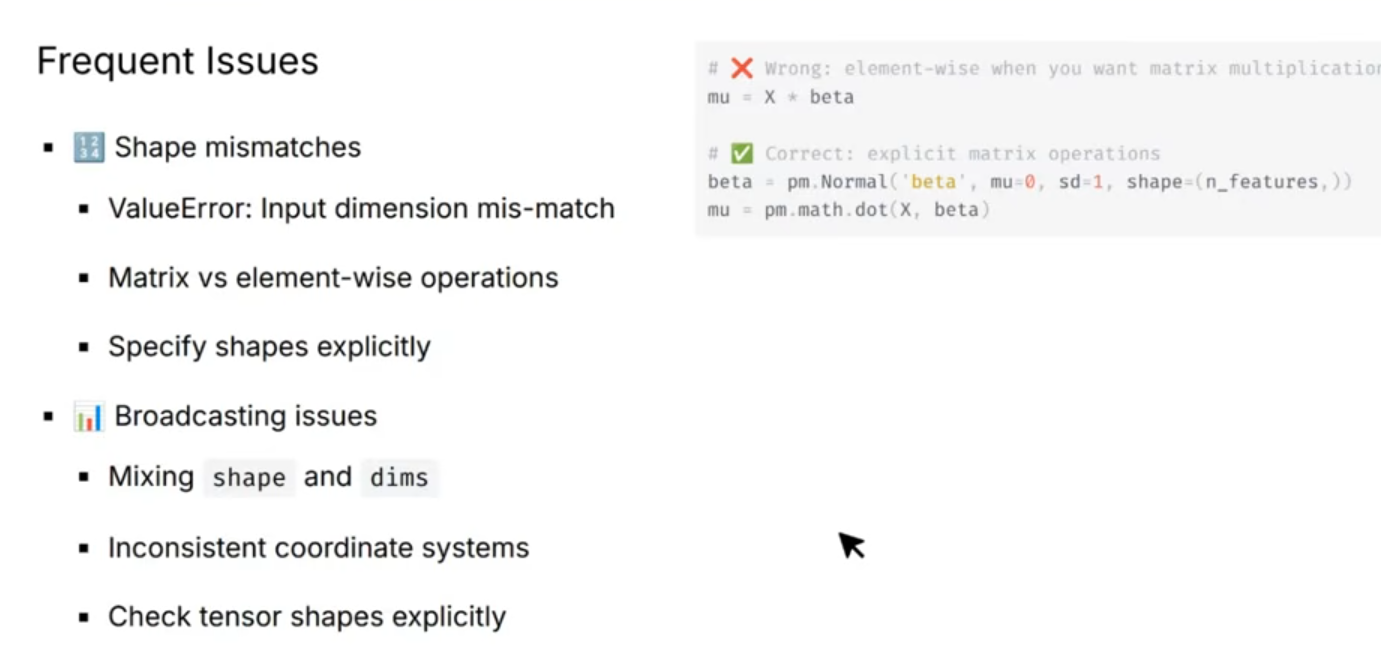


# Sampling the Posterior

In [15]:
with bio_model:
    trace = pm.sample()

e:\miniconda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [16]:
dose = np.array([-0.86, -0.3, -0.05, 0.73])
animals = np.array([5, 5, 5, 5])
deaths = np.array([0, 1, 3, 5])

with pm.Model() as bio_model:

    dose_data = pm.Data('dose_data', dose)
    deaths_data = pm.Data('deaths_data', deaths)

    alpha = pm.Normal('alpha', mu=0, sigma=2.5)
    beta = pm.Normal('beta', mu=0, sigma=2.5)

    theta = pm.math.invlogit(alpha + beta * dose_data)

    deaths_model = pm.Binomial('deaths', n=animals, p=theta, observed=deaths_data)

with bio_model:
    trace = pm.sample()

e:\miniconda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


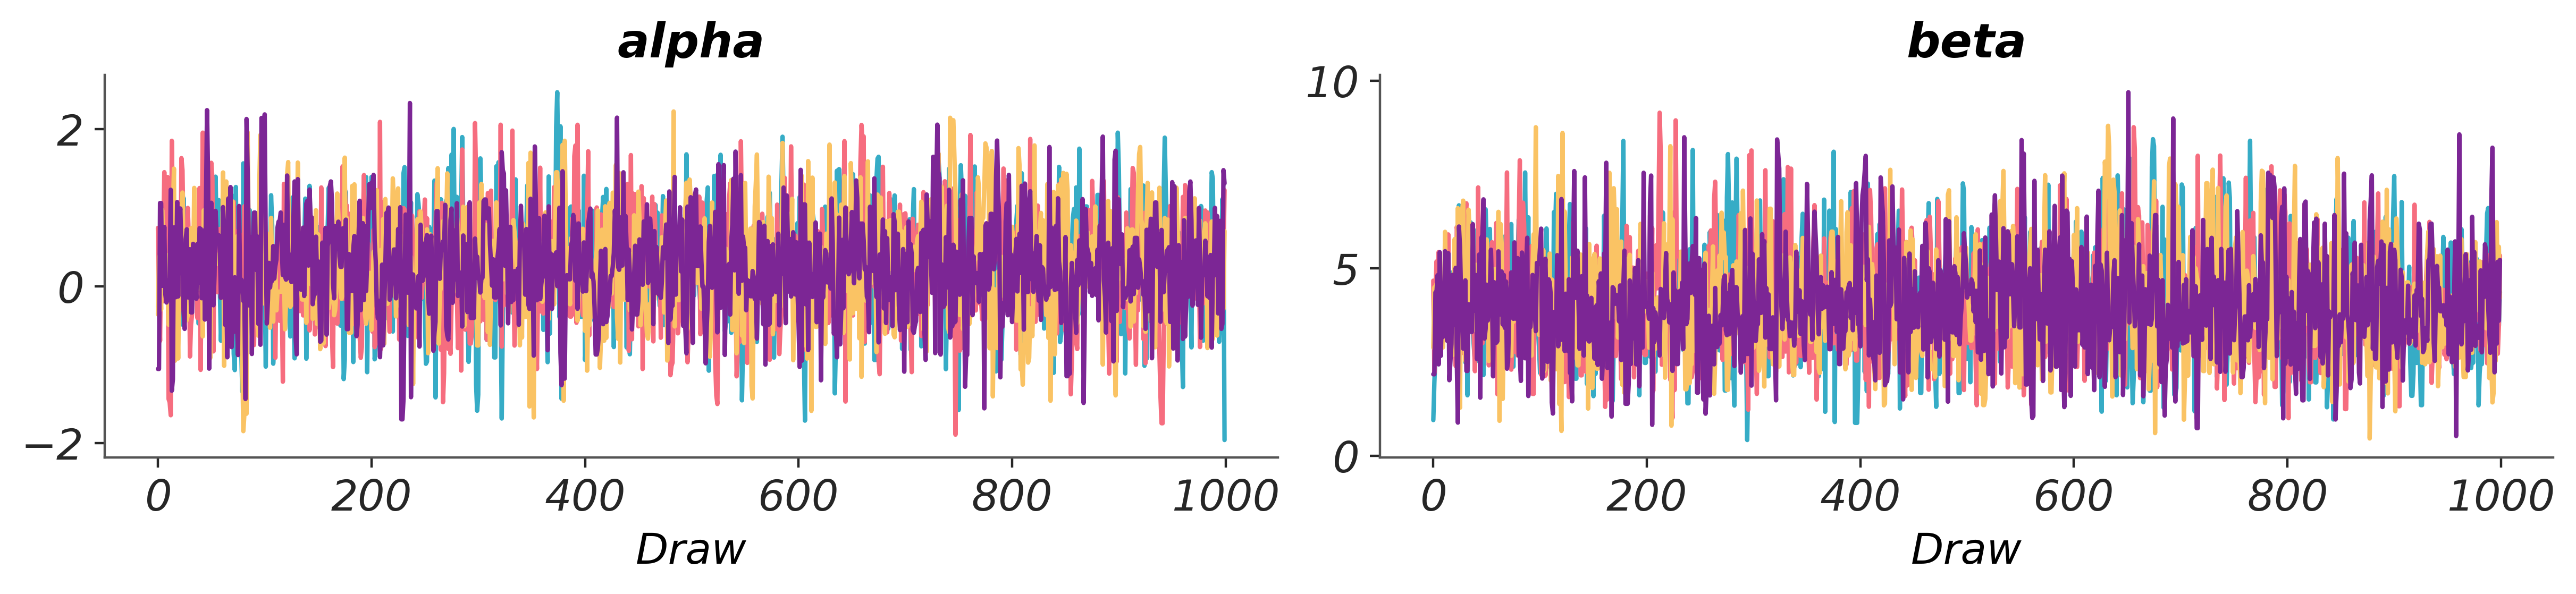

In [18]:
az.plot_trace(trace, var_names=['alpha', 'beta'])

C:\Users\juane\AppData\Local\Temp\ipykernel_8500\1323715149.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


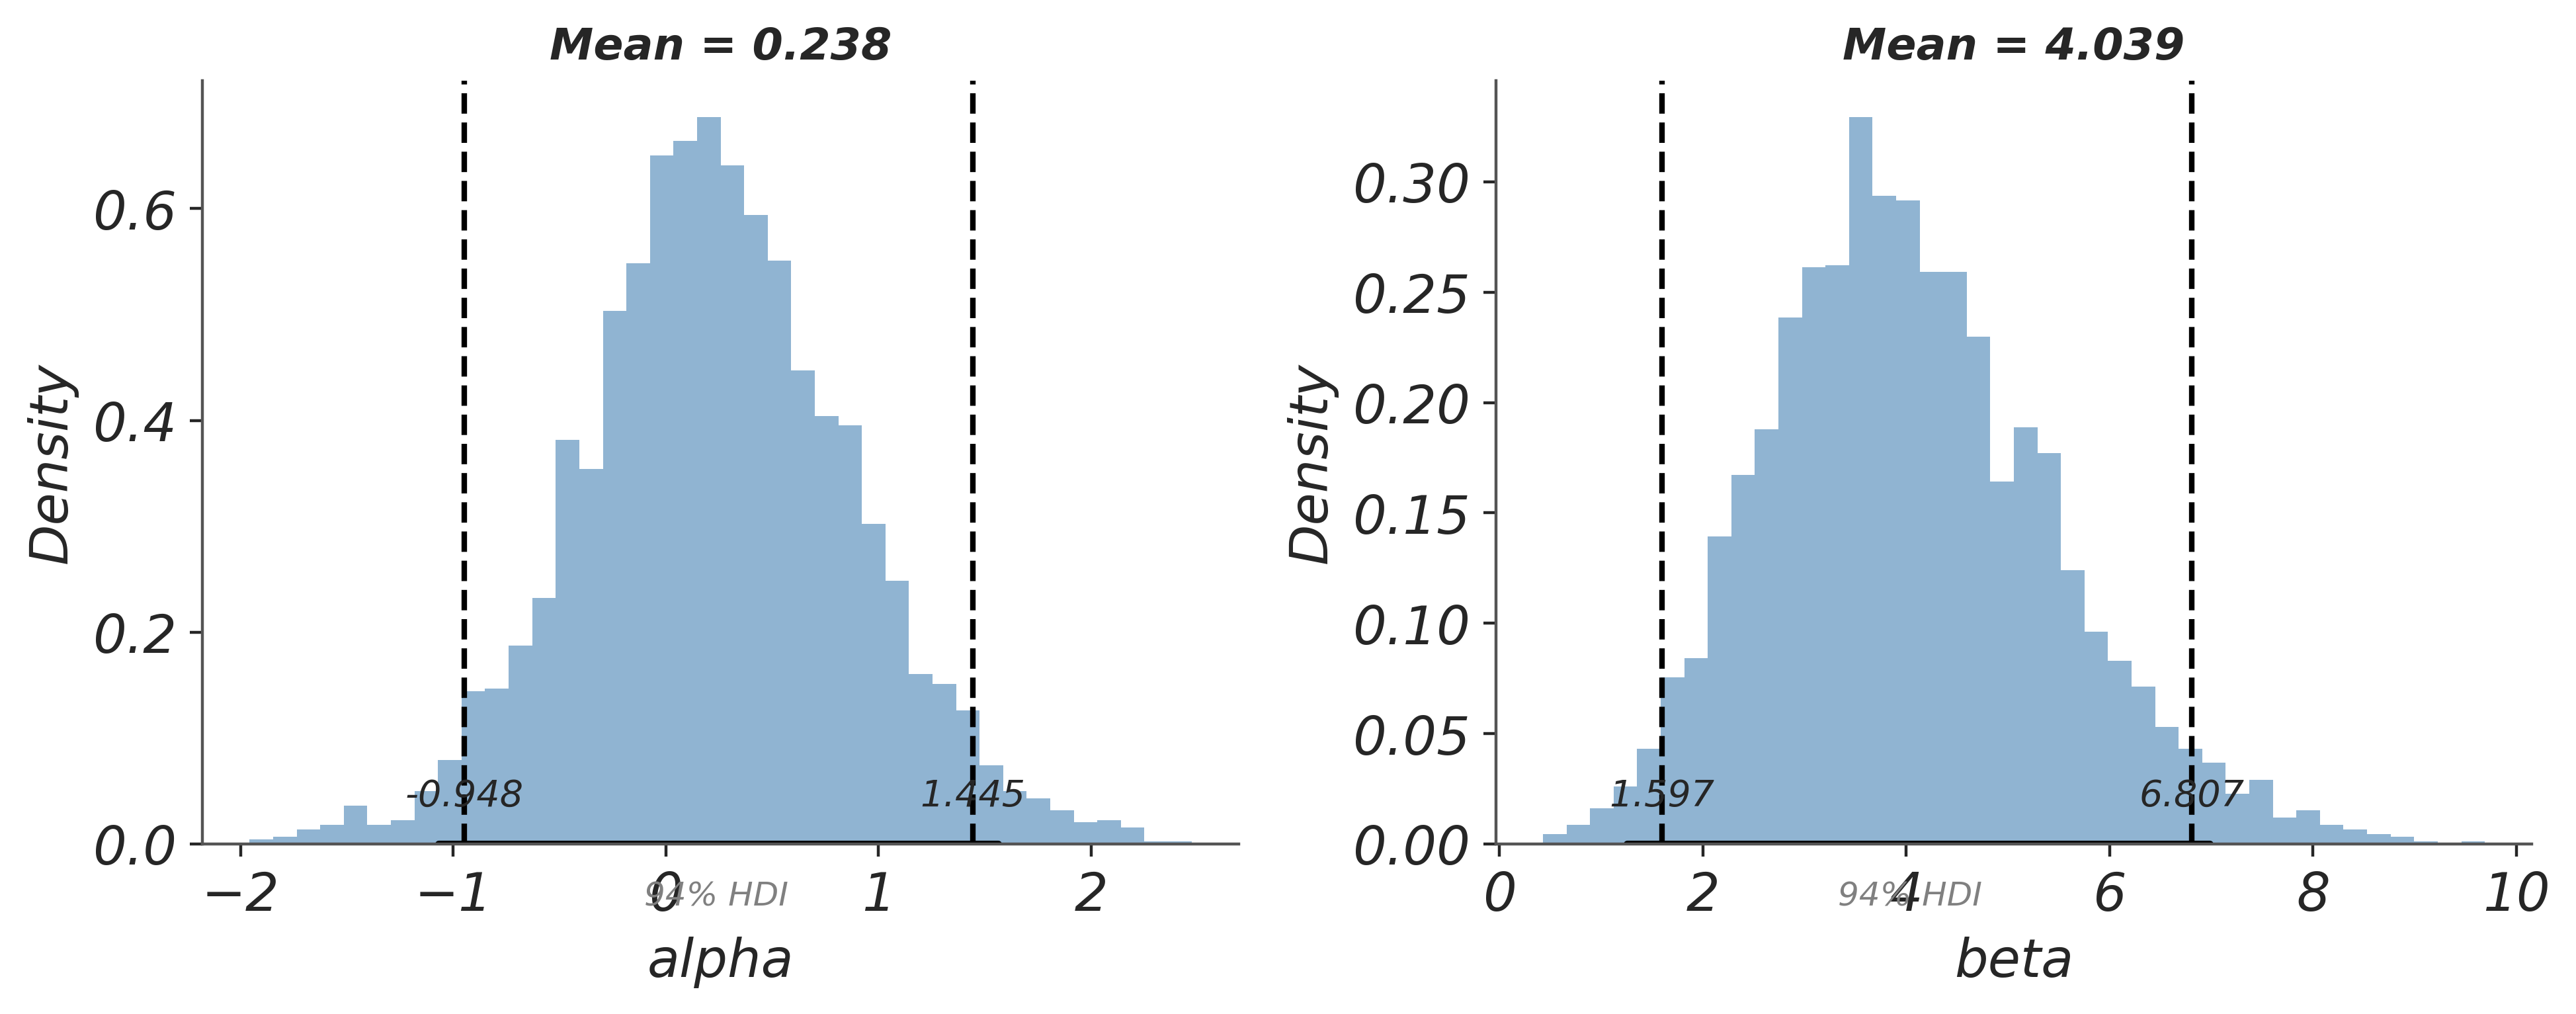

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_posterior_manual(trace, var_names):
    fig, axes = plt.subplots(1, len(var_names), figsize=(5 * len(var_names), 4))
    if len(var_names) == 1:
        axes = [axes]
    
    for ax, var in zip(axes, var_names):
        samples = trace.posterior[var].values.flatten()
        
        # HDI 94%
        hdi = az.hdi(samples, prob=0.94)
        mean_val = samples.mean()
        
        # Plot
        ax.hist(samples, bins=40, density=True, alpha=0.6, color='steelblue')
        
        # HDI line
        ax.axvline(hdi[0], color='black', linestyle='--', linewidth=1.5)
        ax.axvline(hdi[1], color='black', linestyle='--', linewidth=1.5)
        ax.axhline(0, xmin=(hdi[0] - samples.min()) / (samples.max() - samples.min()),
                      xmax=(hdi[1] - samples.min()) / (samples.max() - samples.min()),
                      color='black', linewidth=2)
        
        # Anotaciones
        ax.set_title(f'Mean = {mean_val:.3f}', fontsize=12)
        ax.annotate(f'{hdi[0]:.3f}', xy=(hdi[0], 0), xytext=(hdi[0], ax.get_ylim()[1]*0.05),
                    ha='center', fontsize=10)
        ax.annotate(f'{hdi[1]:.3f}', xy=(hdi[1], 0), xytext=(hdi[1], ax.get_ylim()[1]*0.05),
                    ha='center', fontsize=10)
        ax.annotate('94% HDI', xy=(mean_val, 0), xytext=(mean_val, -ax.get_ylim()[1]*0.08),
                    ha='center', fontsize=9, color='gray')
        
        ax.set_xlabel(var)
        ax.set_ylabel('Density')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_posterior_manual(trace, var_names=['alpha', 'beta'])

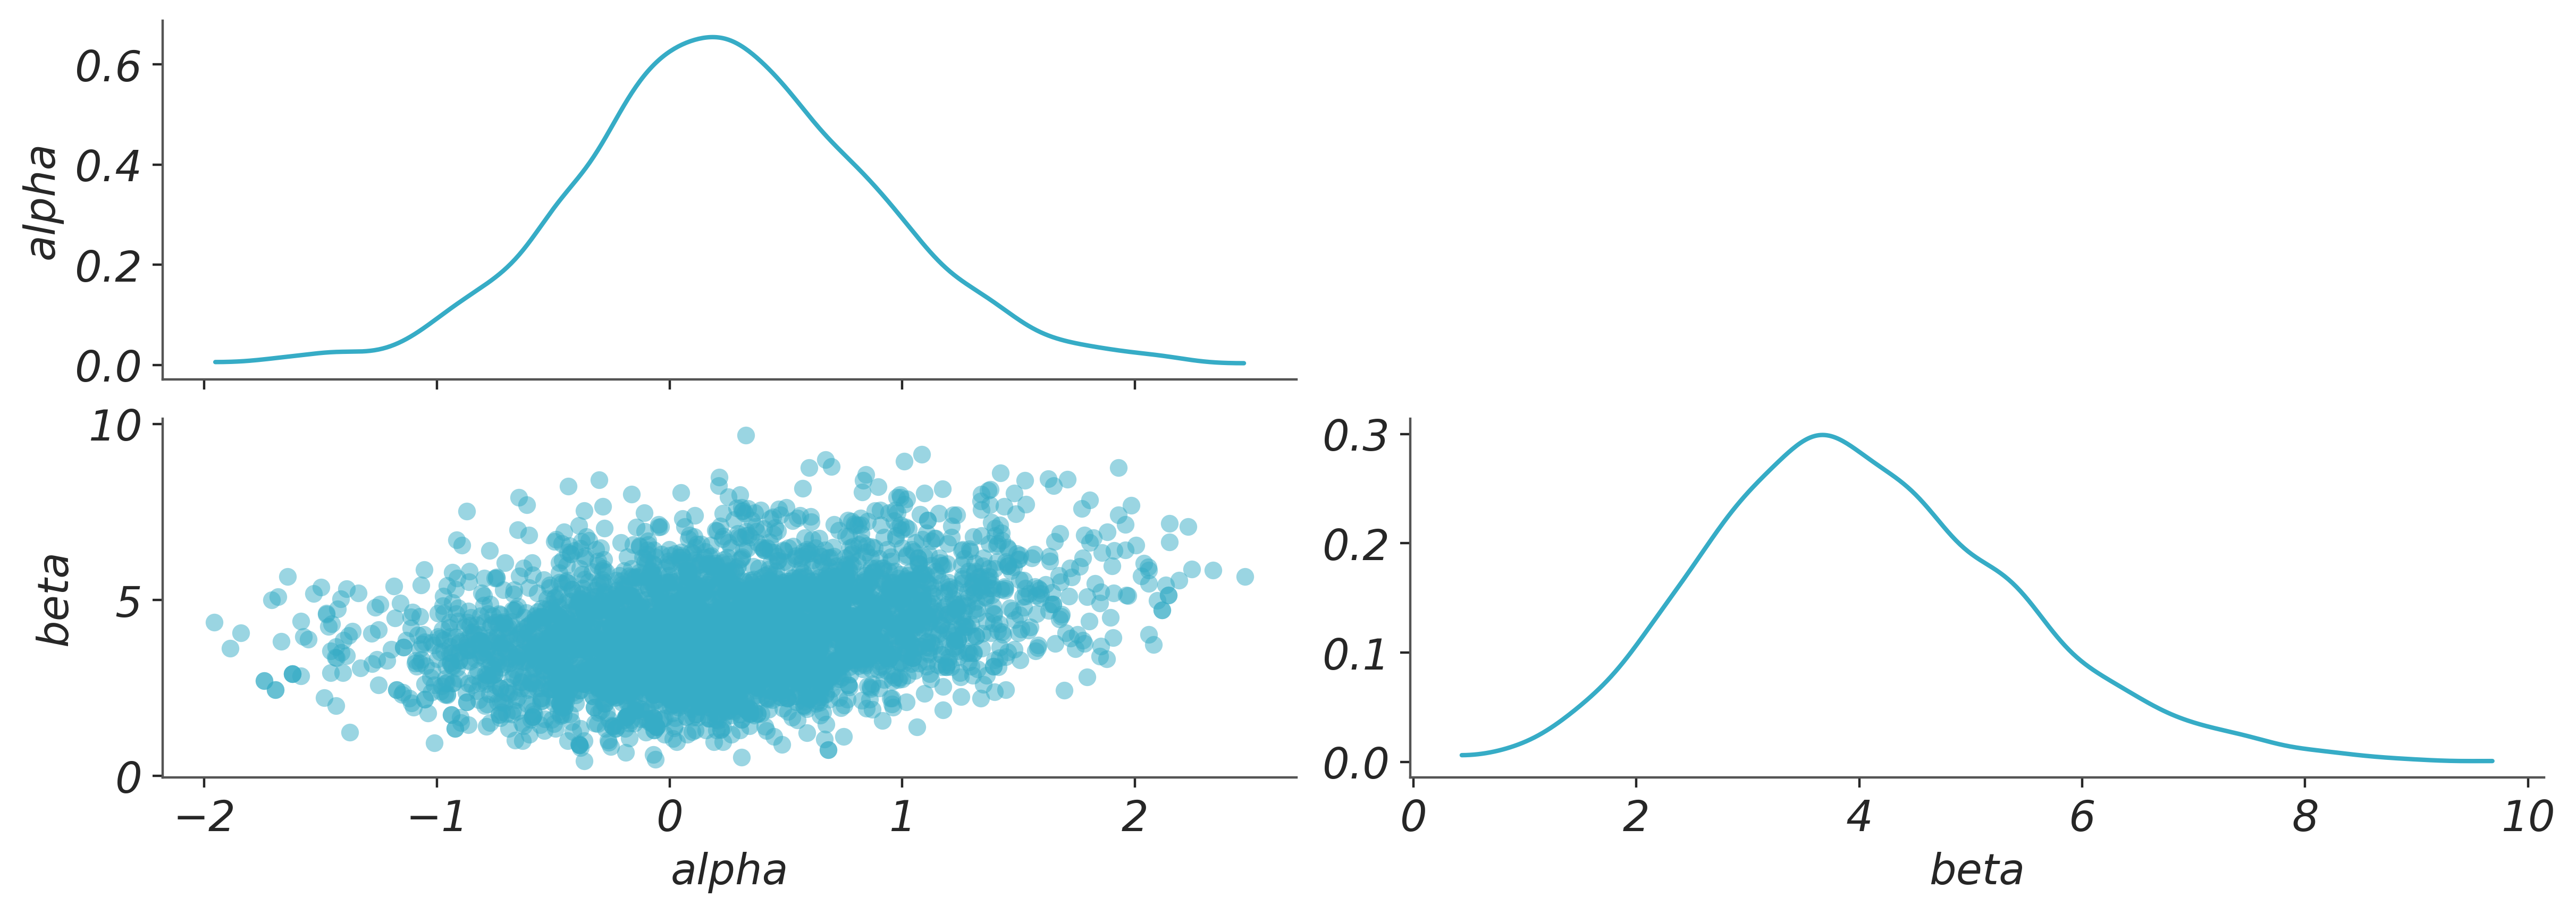

In [27]:
az.plot_pair(trace, var_names=['alpha', 'beta'])

In [28]:
az.summary(trace, var_names=['alpha', 'beta'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.24,0.64,-0.77,1.3,3057,2695,1.00,0.012,0.0087
beta,4.04,1.4,2,6.4,3161,2472,1.00,0.025,0.019


# summary
r_hat convertion diagnostic
ess = effect of sample size


In [46]:

new_doses = np.array([-1.0, 0.0, 1.0, 0.0])
with bio_model:
    pm.set_data({'dose_data': new_doses})
    posterior_pred = pm.sample_posterior_predictive(trace)

pred_mortality = posterior_pred.posterior_predictive['deaths']

Sampling: [deaths]


Output()

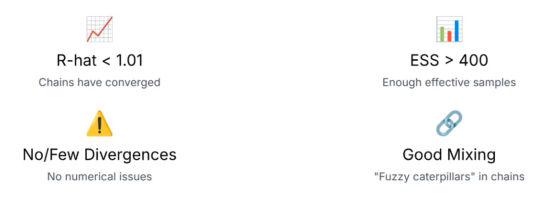

WHERE YOU CAN SEE divergence:

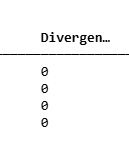

this can happen when you increase "target_acceptance" to closer to 1

recommendation on prior specification problems:

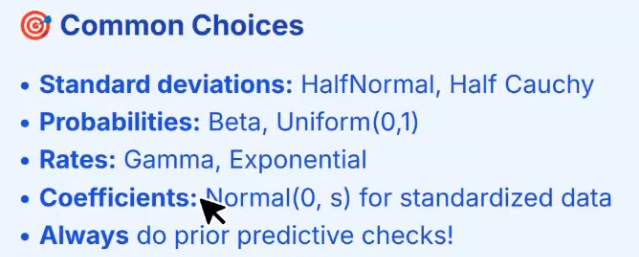



In [47]:
with bio_model:
    trace = pm.sample(nuts_sampler='numpyro')

e:\miniconda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
NUTS[numpyro]: [alpha, beta]


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [49]:
with bio_model:
    point = bio_model.initial_point()
    print(point)
    logp = bio_model.compile_logp()(point)
    print(f"Log-probability at initial point: {logp:.3f}")

{'alpha': array(0.), 'beta': array(0.)}
Log-probability at initial point: -13.621


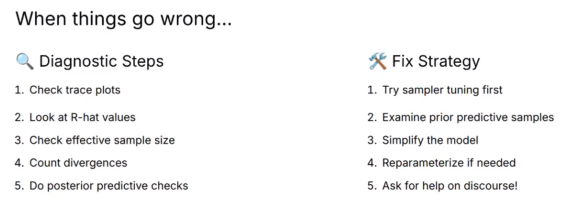


# 